# Import Libraries

In [1]:
import pandas as pd
import os
import pickle
import torch
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments

c:\Users\VICTUS\OneDrive\Documents\Semester_4\ML\ML\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Dataset

In [3]:
train_df = pd.read_csv('../data/data_train_master.csv')
train_df.head(5)

,clean_text,emotion
0,thanks mate! i havent given that idea much tho...,Joy
1,feel you pain. stay strong,Sadness
2,i constantly feel like i'm my husband's best f...,Sadness
3,"been together 6 years, and i think she's the b...",Love
4,"amen! however, see my post about the problem w...",Sadness


# Training

## Data Splitting

Converting into a list because the HuggingFace tokenizer works better with a list of strings

In [4]:
X_train_text = train_df['clean_text'].astype(str).tolist()
y_train_text = train_df['emotion']

## Label Encoding

Because DistilBERT works with numerical computations, the target labels need to be encoded into numerical representations before the training process.

In [5]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_text)
num_classes = len(label_encoder.classes_)

## Tokenization

The DistilBERT tokenizer is loaded using the pre-trained `distilbert-base-uncased` architecture.

In [6]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

In [7]:
train_encodings = tokenizer(
    X_train_text, 
    truncation=True,    # Cuts Sequence > 60 tokens
    padding=True,       # Equalizes Sequence Lengths
    max_length=60
)

## Converting into PyTorch Dataset

The encoded text and labels are converted into a PyTorch Dataset format to make the training process more efficient and compatible with the DistilBERT model.

In [8]:
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmotionDataset(train_encodings, y_train_encoded)

## Installing Architecture

In [9]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', 
    num_labels=num_classes
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Fine-Tuning Model

DistilBERT only requires a small number of epochs because the model is fine-tuned 
from a pre-trained model, and too many epochs may increase the risk of overfitting

The learning rate is set to a very small value (`5e-5`) to avoid disrupting the pre-trained knowledge learned by the DistilBERT model.

In [10]:
training_args = TrainingArguments(
    output_dir='../models/bert/results',
    num_train_epochs=3,
    per_device_train_batch_size=16, # batch (16) -> processes 16 samples at a time
    learning_rate=5e-5,
    report_to="none",
    fp16=True
)

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

c:\Users\VICTUS\OneDrive\Documents\Semester_4\ML\ML\lib\site-packages\accelerate\accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


## Training The Model

In [12]:
trainer.train() 

  9%|▊         | 500/5739 [00:28<04:51, 17.95it/s]

{'loss': 0.9509, 'grad_norm': 8.21740436553955, 'learning_rate': 4.565255270953128e-05, 'epoch': 0.26}


 17%|█▋        | 1000/5739 [00:57<04:11, 18.82it/s]

{'loss': 0.819, 'grad_norm': 6.3652777671813965, 'learning_rate': 4.1296393099843176e-05, 'epoch': 0.52}


 26%|██▌       | 1500/5739 [01:26<04:07, 17.11it/s]

...

 96%|█████████▌| 5500/5739 [05:16<00:12, 18.44it/s]

{'loss': 0.433, 'grad_norm': 7.149439334869385, 'learning_rate': 2.1170935703084163e-06, 'epoch': 2.88}


100%|██████████| 5739/5739 [05:30<00:00, 17.36it/s]

{'train_runtime': 330.6491, 'train_samples_per_second': 277.672, 'train_steps_per_second': 17.357, 'train_loss': 0.6180350687014016, 'epoch': 3.0}


TrainOutput(global_step=5739, training_loss=0.6180350687014016, metrics={'train_runtime': 330.6491, 'train_samples_per_second': 277.672, 'train_steps_per_second': 17.357, 'total_flos': 1425347388319680.0, 'train_loss': 0.6180350687014016, 'epoch': 3.0})

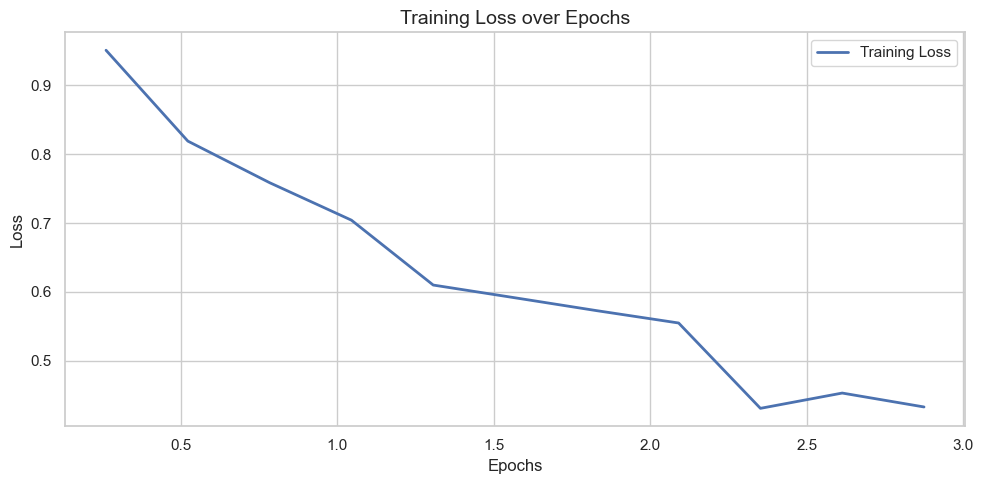

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

history = trainer.state.log_history

epochs = []
train_loss = []

for entry in history:
    if 'loss' in entry and 'epoch' in entry:
        epochs.append(entry['epoch'])
        train_loss.append(entry['loss'])

# Graphs
plt.figure(figsize=(10, 5))
if train_loss:
    plt.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2)
    
plt.title('Training Loss over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Dump Model

In [13]:
model.save_pretrained('../models/bert')
tokenizer.save_pretrained('../models/bert')

with open('../models/bert/label_encoder.pkl', 'wb') as handle:
    pickle.dump(label_encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)